# GHSL — built-up surface

Download GHS-BUILT-S 2020 at 100 m over the Lisbon AOI: the built-up surface (m² per cell).

In [1]:
import tempfile
from earthlens import EarthLens
out = tempfile.mkdtemp()
paths = EarthLens(
    data_source='ghsl', variables=['GHS_BUILT_S'],
    start='2020-01-01', end='2020-12-31',
    aoi=[-9.20, 38.68, -9.10, 38.78], path=out,
).download(progress_bar=False)
paths

2026-05-28 22:47:40 | INFO | pyramids.base.config | Logging is configured.


2026-05-28 22:47:41 | WARNING | pyramids.base.config.gdal | GDAL[6] Band data type of UInt16 cannot represent the specified NoData value of nan


[WindowsPath('C:/Users/main/AppData/Local/Temp/claude/tmp1vv7yg4i/GHS_BUILT_S_E2020_100m_epsg4326.tif')]

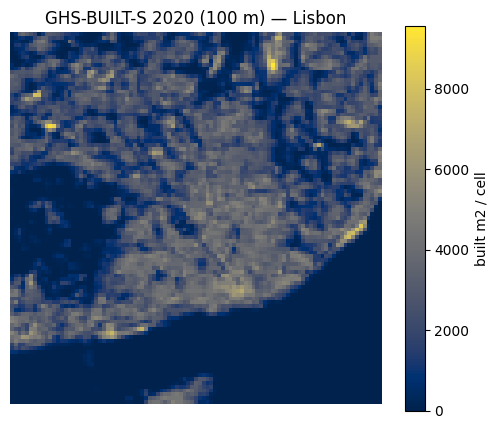

In [2]:
import numpy as np, matplotlib.pyplot as plt
from pyramids.dataset import Dataset
arr = np.asarray(Dataset.read_file(str(paths[0])).read_array(), dtype='float32')
arr = arr[0] if arr.ndim == 3 else arr
arr = np.where(arr < 0, np.nan, arr)
plt.figure(figsize=(6, 5))
plt.imshow(arr, cmap='cividis')
plt.colorbar(label='built m2 / cell')
plt.title('GHS-BUILT-S 2020 (100 m) — Lisbon')
plt.axis('off')
plt.show()